# Exercise: Transfer Learning and Semantic Segmentation

This notebook contains Image classification using transfer learning.

**Learning Objectives**

In this exercise you will:
- Fine-tuning of a pretrained **Convolutional Neural Network (CNN)** using Keras
- Fine-tune it on a **real-world image dataset**
- Training using **data augmentation** and **early stopping**
- Visualize results with **confusion matrix**


## Image Classification with Transfer Learning

**Objective:** Build an image classification model using a pretrained CNN (MobileNetV2, ResNet50, or EfficientNetV2S) and fine-tune it on a custom animal dataset.

## 1. Datasets (Suggestions)

- Animals-10 (Kaggle) https://www.kaggle.com/datasets/alessiocorrado99/animals10
- Cats vs Dogs (Kaggle) https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
- 
Directory structure:
```
dataset/
  train/
    cat/
    dog/
    horse/

(Optional)

  val/
    cat/
    dog/
    horse/
```

In [2]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


## 2. Data Loading and Augmentation

In [ ]:

img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255,     
                             validation_split=0.2)

train_data = train_gen.flow_from_directory(
    "/home/don/gitmal/L14-CNN-II/data/train", # Change path to your downloaded dataset (Path on GPU cluster for animal dataset)
    target_size=img_size,
    batch_size=batch_size,
    subset='training',
    class_mode="categorical"
)

val_data = val_gen.flow_from_directory(
    "/home/don/gitmal/L14-CNN-II/data/train",  # Change path if separate validation dataset (Path on GPU cluster for animal dataset)
    target_size=img_size,
    batch_size=batch_size,
    subset='validation', 
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
print(class_names)


## 3. Build Transfer Learning Model

In [13]:

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(img_size[0], img_size[1], 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(len(class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_3[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']      

## 4. Training with Early Stopping

In [ ]:

early_stop = tf.keras.callbacks.EarlyStopping(
    patience=5, restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop]
)


## 5. Plot Training Curves

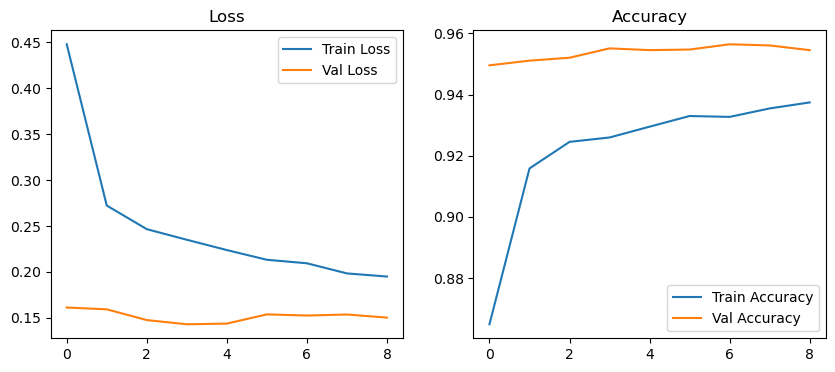

In [16]:

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.show()


### 6. Evaluation Metrics

In [ ]:

y_true = val_data.classes
y_pred = np.argmax(model.predict(val_data), axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

#cm = confusion_matrix(y_true, y_pred)

#plt.figure(figsize=(6,5))
#sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#            xticklabels=class_names, yticklabels=class_names) # Not working on some versions of Seaborn
#plt.xlabel("Predicted")
#plt.ylabel("True")
#plt.title("Confusion Matrix")
#plt.show()


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
plt.show()

ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize="true", values_format=".0%")
plt.show()

## 7. Questions

- Q7.a) Explain the results: precision, recall, f1-score and support?
- Q7.b) What is the difference between macro and weighted avg accuracy?
- Q7.c) What happens if you unfreeze the last layers of the pretrained model?
- Q7.d) Describe the different types of data augmentation that are used in the example.
- Q7.e) How does data augmentation influence overfitting?
- Q7.f) What is the purpose of the batch normalization layers in MobileNet? 
- Q7.g) Change the model example to use ResNet50 and EfficientNetV2S (See https://keras.io/api/applications/)
- Q7.h) Compare MobileNetV2 with ResNet50 and EfficientNetV2S (Compare accuracy and number of training epochs in a table)

### Deliverables:

- Completed notebook or report with experiments
- Include answers to questions
- Short written reflection on results

REVISIONS||
:- | :-
2022-01-23| KBE, initial.                  
2022-03-16| KBE, updated confusion matrix